In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Question 4 — Otsu mask + foreground histogram equalization (`woman.jpg`)

This matches the assignment setup: **a person in front of a bright opening** (door/window). **Otsu** splits **dark interior + figure** from the **bright outside**; we treat the **smaller** connected class as **foreground** (woman + room) when that matches the scene.

**(a)** Grayscale image → **Otsu** automatic threshold → binary **foreground** mask. OpenCV returns the optimal threshold $T^*$.

**(b)** **Histogram equalization** uses counts **only from foreground pixels** (same CDF/LUT idea as global HE, but $MN$ is the number of masked pixels). Background stays unchanged. In your report, describe what appears inside the mask (e.g. **facial detail**, **hair and clothing texture**, **wall and floor** in the room)—the markdown below is a **starting point** after viewing `woman.jpg`.

Otsu threshold T* = 101 (intensity 0–255)
Foreground mask: white = FG after optional invert so the smaller region is FG.


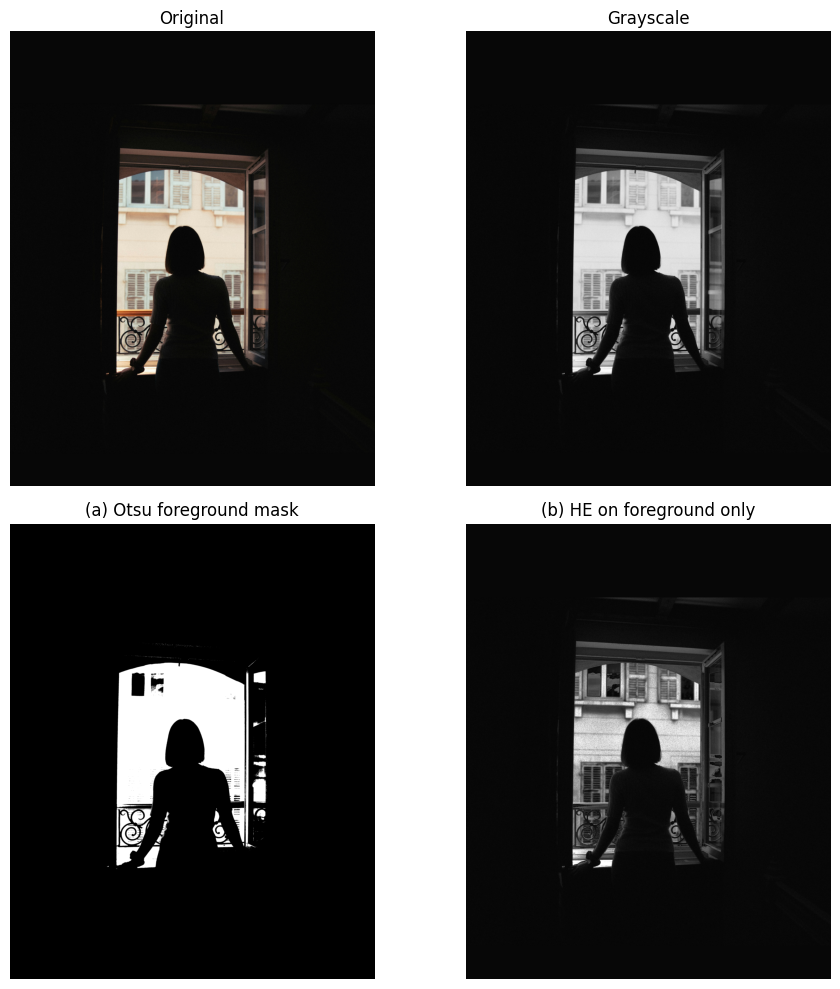

In [ ]:
def histogram_equalize_masked(gray: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Equalize only pixels where mask > 0; others unchanged. Uses own CDF on FG only."""
    if gray.dtype != np.uint8 or gray.ndim != 2:
        raise ValueError("Expected uint8 grayscale.")
    fg = mask > 0
    if not np.any(fg):
        return gray.copy()

    vals = gray[fg]
    n = int(vals.size)
    hist = np.bincount(vals, minlength=256).astype(np.float64)
    cdf = np.cumsum(hist)
    first = int(np.argmax(hist > 0))
    cdf_min = cdf[first]
    denom = n - cdf_min
    if denom <= 0:
        return gray.copy()

    lut = np.round((cdf - cdf_min) / denom * 255.0).astype(np.uint8)
    out = gray.copy()
    out[fg] = lut[gray[fg]]
    return out


path = "images/woman.jpg"
bgr = cv2.imread(path)
if bgr is None:
    raise FileNotFoundError(path)

gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

# Otsu: OpenCV returns threshold T and binary image
T_otsu, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

n_fg_white = int(np.count_nonzero(binary == 255))
n_fg_black = int(np.count_nonzero(binary == 0))
if n_fg_white <= n_fg_black:
    fg_mask = binary
else:
    fg_mask = cv2.bitwise_not(binary)

print(f"Otsu threshold T* = {T_otsu:.6g} (intensity 0–255)")
print(
    "Foreground mask: white = FG after optional invert so the smaller region is FG."
)

eq_fg = histogram_equalize_masked(gray, fg_mask)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original")
axes[0, 1].imshow(gray, cmap="gray")
axes[0, 1].set_title("Grayscale")
axes[1, 0].imshow(fg_mask, cmap="gray")
axes[1, 0].set_title("(a) Otsu foreground mask")
axes[1, 1].imshow(eq_fg, cmap="gray")
axes[1, 1].set_title("(b) HE on foreground only")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

### (b) What hidden features show up? *(for `woman.jpg` — refine after your run)*

Histogram equalization on **only the foreground (woman + interior)** redistributes gray levels there, so **local contrast** increases while the **bright doorway/window** stays at the original intensities. On this kind of scene you often see:

- **More detail in darker clothing** and **hair** where values were squeezed into a narrow gray band.
- **Facial structure** (eyes, nose, mouth) and **skin texture** becoming clearer if they sat in mid-tones before HE.
- **Room cues** — **walls, floor, or objects** behind the figure — if they fall in the same Otsu class as the interior.

Adjust the list with **what you actually see** in `eq_fg` vs `gray` inside the mask. If the mask looks inverted (outside labeled foreground), flip with `fg_mask = cv2.bitwise_not(binary)`.